# (24) neg. binomial / poisson / gamma / inv. gaussian

device = ```cuda:1```

**Motivation**: <br>

In [1]:
# HIDE CODE


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

from mcfe.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

In [3]:
from mcfe.main.load_model import load_model
from mcfe.figures.pairwise import regression_plot

## Negative Binomial

In [4]:
wandb_run_id = 'pal-lab/MCFE/343gyvw7'

tr, meta = load_model(target_path=wandb_run_id, verbose=True)

Path 'pal-lab/MCFE/343gyvw7' matches WandB format. Fetching config...

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/hadi/.netrc.


# params: 263.4 K

Successfully loaded model from 
/home/hadi/Projects/MCFE/checkpoints/nb_vH16-wht_z-512/b(1000)-ep(3000)-lr(0.001)_betas(kl-1,recon-1)/2026_02_24,18
:57

Checkpoint File: NegativeBinomialVAE+Trainer-3000_(2026_02_24,19:30).pt

In [5]:
print(meta)

{
    'created_timestamp': '2026_02_24,18:57',
    'checkpoint': 3000,
    'global_step': 309000,
    'root': 
'/home/hadi/Projects/MCFE/checkpoints/nb_vH16-wht_z-512/b(1000)-ep(3000)-lr(0.001)_betas(kl-1,recon-1)/2026_02_24,1
8:57',
    'file': 'NegativeBinomialVAE+Trainer-3000_(2026_02_24,19:30).pt'
}

In [6]:
list(tr.stats)

['lr',
 'temp',
 'r_max',
 'alpha_min',
 'n_exp',
 'eval/r2',
 'eval/mse',
 'eval/kl',
 'eval/elbo',
 'eval/kl_diag',
 'eval/overall_sparse_coding',
 'sprs/portion_zeros',
 'sprs/population',
 'sprs/lifetime']

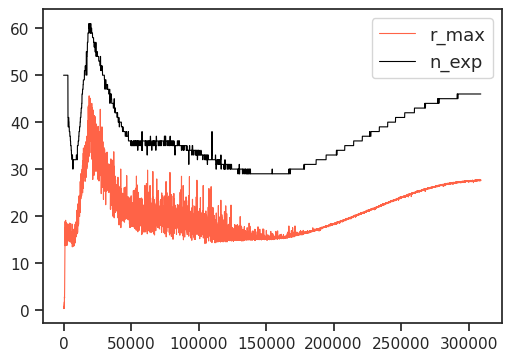

In [7]:
r_max = np.array(list(tr.stats['r_max'].values()))
n_exp = np.array(list(tr.stats['n_exp'].values()))

fig, ax = create_figure(1, 1, (5, 3.5))
ax.plot(r_max, lw=0.8, label='r_max', color='tomato')
ax.plot(n_exp, lw=0.8, label='n_exp', color='k')
add_legend(ax, fontsize=13)
plt.show()

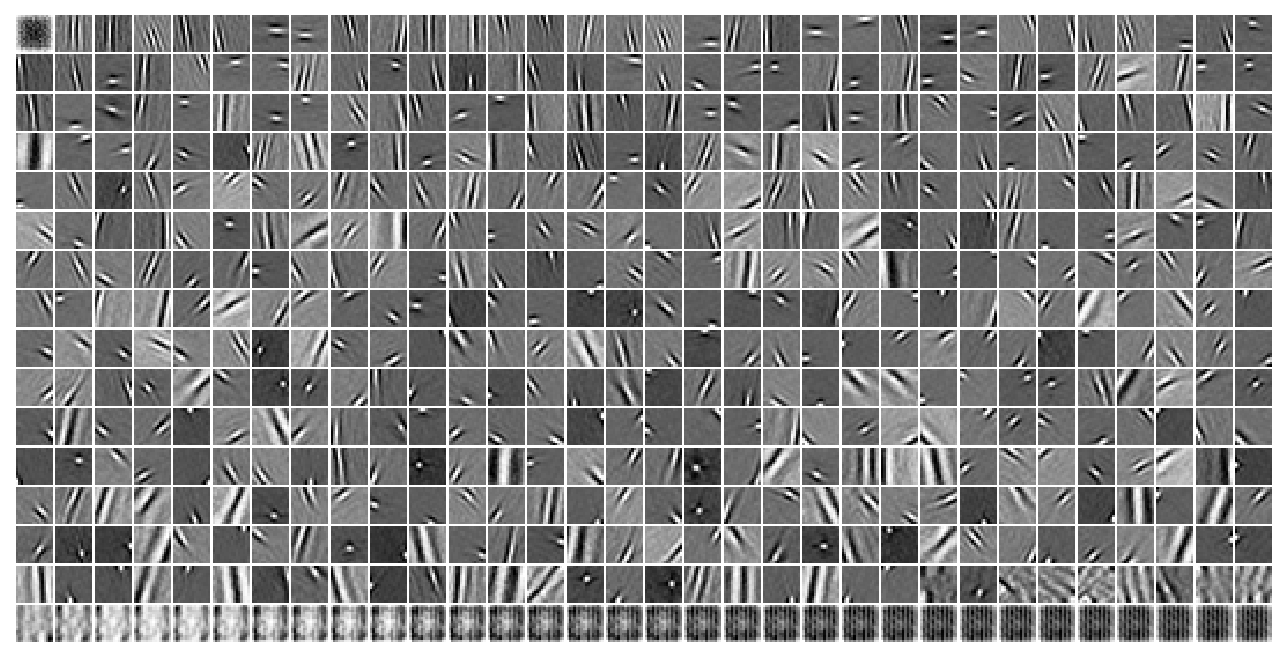

In [8]:
tr.model.show();

In [9]:
u0 = tonp(tr.model.u_init[0].squeeze())
log_alphas = tonp(tr.model.log_alpha.squeeze())

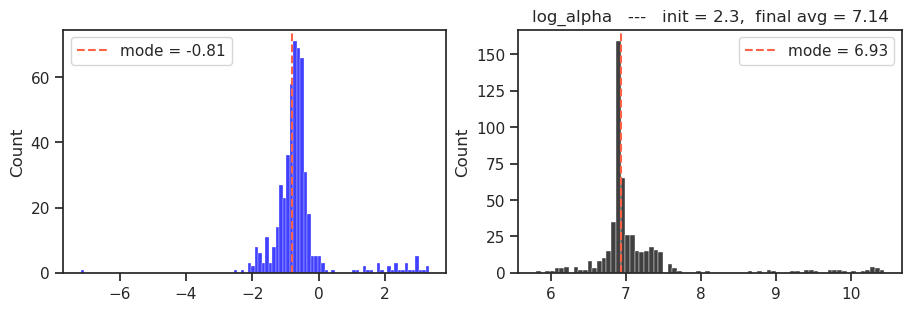

In [10]:
fig, axes = create_figure(1, 2, (9, 3))

sns.histplot(u0, color='blue', ax=axes[0])
sns.histplot(log_alphas, color='k', ax=axes[1])

u0_mode = sp_stats.mode(np.round(u0, 3)).mode
log_alphas_mode = sp_stats.mode(np.round(log_alphas, 3)).mode

axes[0].axvline(
    u0_mode,
    color='tomato',
    ls='--',
    label=f'mode = {u0_mode:0.2f}',
)
axes[1].axvline(
    log_alphas_mode,
    color='tomato',
    ls='--',
    label=f'mode = {log_alphas_mode:0.2f}',
)

axes[1].set_title(
    f"log_alpha   ---   "
    f"init = {tr.model.cfg.log_alpha_init},  "
    f"final avg = {log_alphas.mean():0.3g}"
)

add_legend(axes)

plt.show()

In [11]:
bad_indices = (u0 < -4) | (log_alphas > 8)
good_indices = np.arange(len(u0))[~bad_indices]

print(f"total num removed indices:  {bad_indices.sum()}")

total num removed indices:  34

In [12]:
u0_good = u0[good_indices]
log_alphas_good = log_alphas[good_indices]

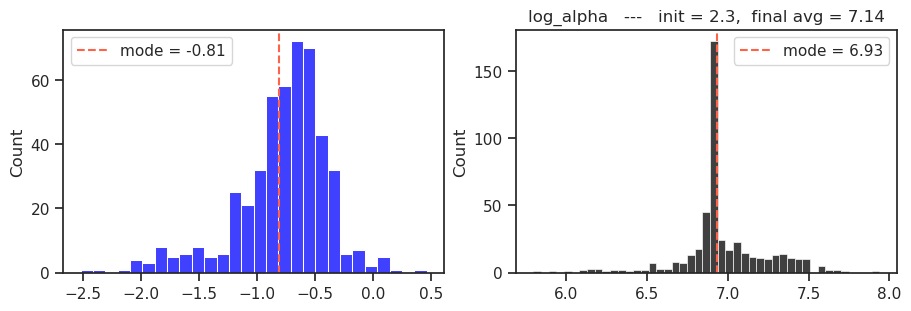

In [13]:
fig, axes = create_figure(1, 2, (9, 3))


sns.histplot(u0_good, color='blue', ax=axes[0])
sns.histplot(log_alphas_good, color='k', ax=axes[1])

u0_mode = sp_stats.mode(np.round(u0_good, 3)).mode
log_alphas_mode = sp_stats.mode(np.round(log_alphas_good, 3)).mode

axes[0].axvline(
    u0_mode,
    color='tomato',
    ls='--',
    label=f'mode = {u0_mode:0.2f}',
)
axes[1].axvline(
    log_alphas_mode,
    color='tomato',
    ls='--',
    label=f'mode = {log_alphas_mode:0.2f}',
)

axes[1].set_title(
    f"log_alpha   ---   "
    f"init = {tr.model.cfg.log_alpha_init},  "
    f"final avg = {log_alphas.mean():0.3g}"
)

add_legend(axes)

plt.show()

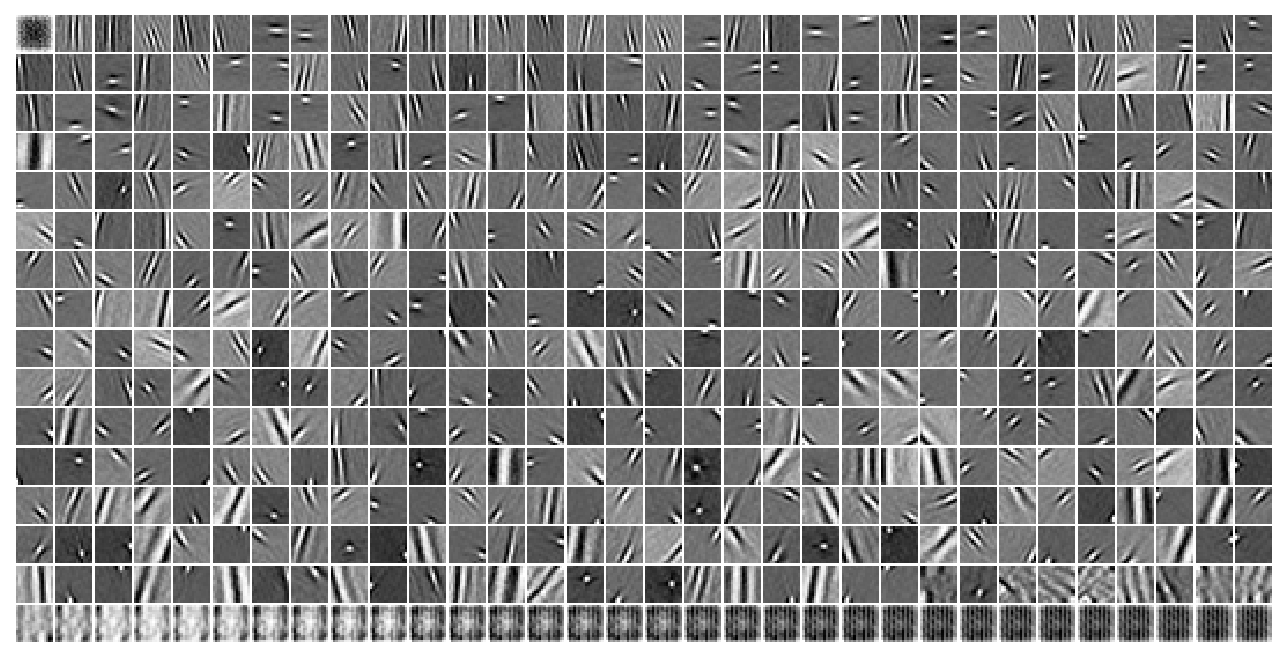

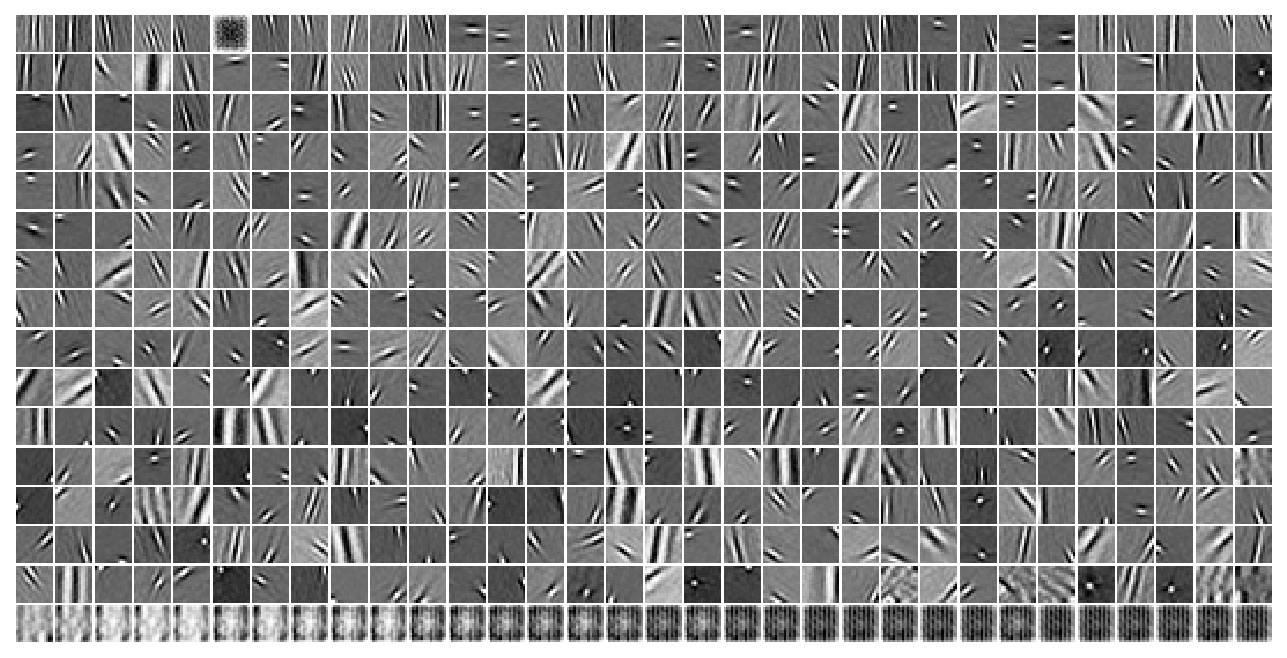

In [14]:
tr.model.show(order=np.argsort(u0));
tr.model.show(order=np.argsort(log_alphas));

bad ones: last 1 row(s), plus the last 2 elements from the row above

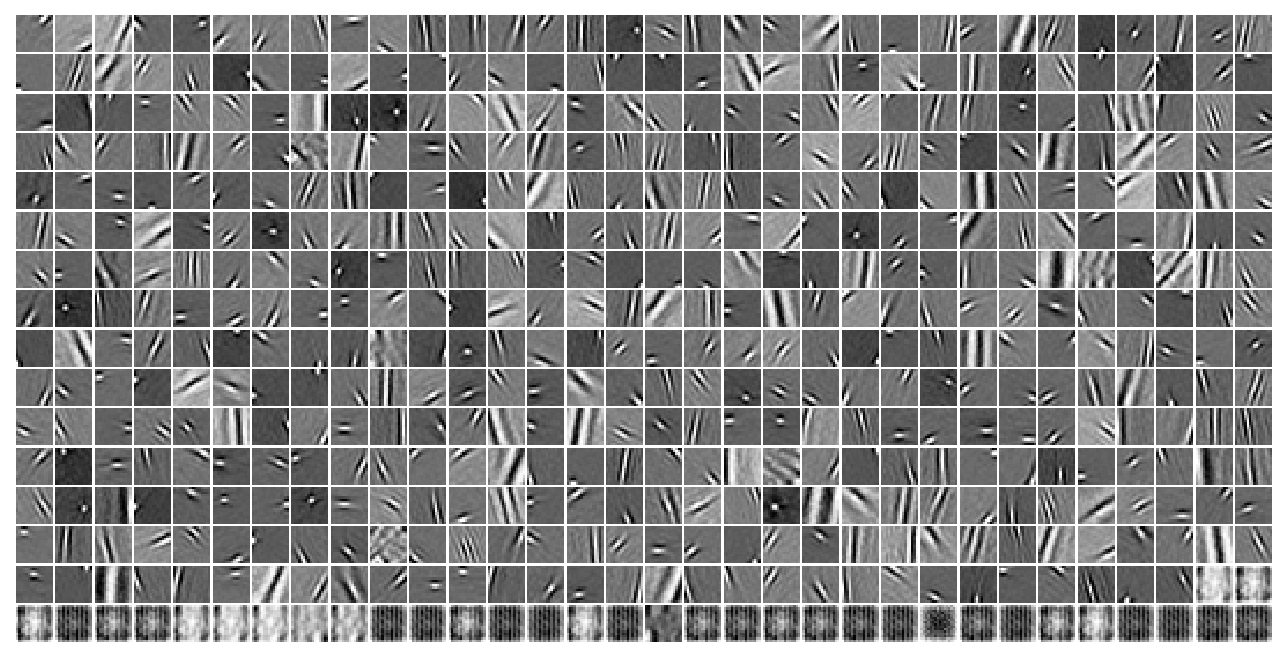

In [15]:
bad_rows = bad_indices.sum() // (512 // 16)
bad_elements = bad_indices.sum() % (512 // 16)

print(f"bad ones: last {bad_rows} row(s), plus the last {bad_elements} elements from the row above")

tr.model.show(order=np.argsort(bad_indices));

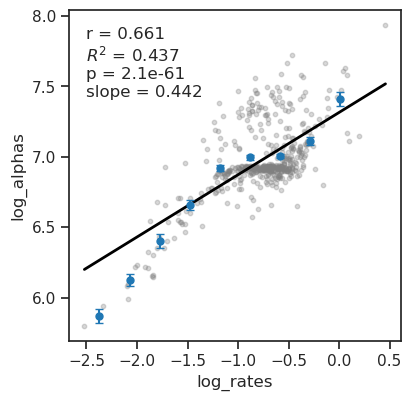

In [16]:
_ = regression_plot(
    x=u0[good_indices],
    y=log_alphas[good_indices],
    xlabel='log_rates',
    ylabel='log_alphas',
)
plt.show()

In [17]:
api = wandb.Api()
run = api.run(wandb_run_id)
print(run.summary)

{'_runtime': 2003.075652757, '_step': 309000, '_timestamp': 1771990252.0882654, '_wandb': {'runtime': 2003}, 
'coeffs/alpha_min': 329.538251186939, 'coeffs/beta_kl': 1, 'coeffs/lr': 1.0000002113638108e-05, 'coeffs/n_exp': 46,
'coeffs/r_max': 27.653454293595985, 'eval/elbo': 167.2991180419922, 'eval/kl': 32.042091369628906, 'eval/kl_diag': 
0.06258164346218109, 'eval/mse': 135.25701904296875, 'eval/overall_sparse_coding': 0.5865344746007893, 'eval/r2': 
0.27599164843559265, 'figs/phi': {'_type': 'image-file', 'format': 'png', 'height': 320, 'path': 
'media/images/figs/phi_309000_d0436000ae964449dbec.png', 'sha256': 
'd0436000ae964449dbec7f38407d72b1a8552e401abe4c70305795d2a2c767ce', 'size': 233497, 'width': 640}, 'sprs/lifetime':
0.6739522218704224, 'sprs/population': 0.888663649559021, 'sprs/portion_zeros': 0.5952071064662353, 'train/elbo': 
166.30950927734375, 'train/loss': 166.30950927734375, 'train/loss_kl': 32.37336730957031, 'train/loss_mse': 
133.93614196777344, 'train/n_active': 481, 'train/n_active_ratio': 0.939453125, 'train/perdim_kl': 
0.06322923302650452, 'train/perdim_mse': 0.523188054561615}

## Poisson

In [18]:
wandb_run_id = 'pal-lab/MCFE/qloaoj7x'

tr, meta = load_model(target_path=wandb_run_id, verbose=True)

Path 'pal-lab/MCFE/qloaoj7x' matches WandB format. Fetching config...

# params: 262.9 K

Successfully loaded model from 
/home/hadi/Projects/MCFE/checkpoints/pois_vH16-wht_z-512/b(1000)-ep(3000)-lr(0.001)_betas(kl-1,recon-1)/2026_02_24,
18:57

Checkpoint File: PoissonVAE+Trainer-3000_(2026_02_24,19:23).pt

In [19]:
print(meta)

{
    'created_timestamp': '2026_02_24,18:57',
    'checkpoint': 3000,
    'global_step': 309000,
    'root': 
'/home/hadi/Projects/MCFE/checkpoints/pois_vH16-wht_z-512/b(1000)-ep(3000)-lr(0.001)_betas(kl-1,recon-1)/2026_02_24
,18:57',
    'file': 'PoissonVAE+Trainer-3000_(2026_02_24,19:23).pt'
}

In [20]:
list(tr.stats)

['lr',
 'temp',
 'r_max',
 'alpha_min',
 'n_exp',
 'eval/r2',
 'eval/mse',
 'eval/kl',
 'eval/elbo',
 'eval/kl_diag',
 'eval/overall_sparse_coding',
 'sprs/portion_zeros',
 'sprs/population',
 'sprs/lifetime']

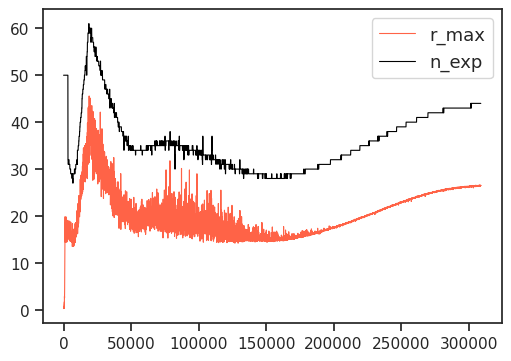

In [21]:
r_max = np.array(list(tr.stats['r_max'].values()))
n_exp = np.array(list(tr.stats['n_exp'].values()))

fig, ax = create_figure(1, 1, (5, 3.5))
ax.plot(r_max, lw=0.8, label='r_max', color='tomato')
ax.plot(n_exp, lw=0.8, label='n_exp', color='k')
add_legend(ax, fontsize=13)
plt.show()

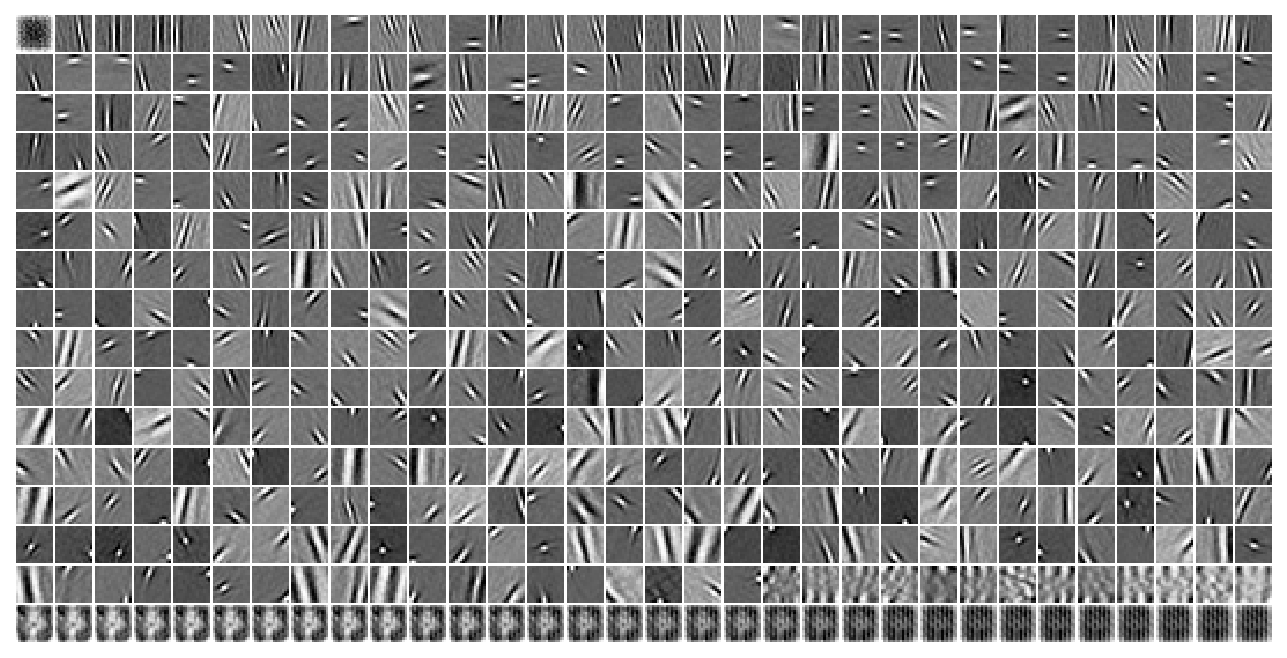

In [22]:
tr.model.show();

In [23]:
u0 = tonp(tr.model.u_init[0].squeeze())

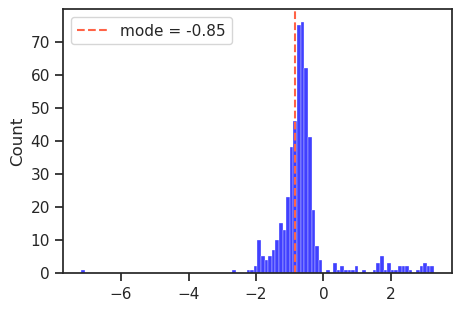

In [24]:
fig, ax = create_figure(1, 1, (4.5, 3))

sns.histplot(u0, color='blue', ax=ax)

u0_mode = sp_stats.mode(np.round(u0, 3)).mode
ax.axvline(
    u0_mode,
    color='tomato',
    ls='--',
    label=f'mode = {u0_mode:0.2f}',
)
add_legend(ax)
plt.show()

In [25]:
bad_indices = (u0 < -4) | (u0 > 0)
good_indices = np.arange(len(u0))[~bad_indices]

print(f"total num removed indices:  {bad_indices.sum()}")

total num removed indices:  46

In [26]:
u0_good = u0[good_indices]

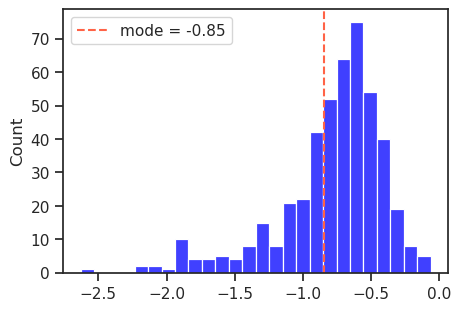

In [27]:
fig, ax = create_figure(1, 1, (4.5, 3))

sns.histplot(u0_good, color='blue', ax=ax)

u0_mode = sp_stats.mode(np.round(u0_good, 3)).mode
ax.axvline(
    u0_mode,
    color='tomato',
    ls='--',
    label=f'mode = {u0_mode:0.2f}',
)
add_legend(ax)

plt.show()

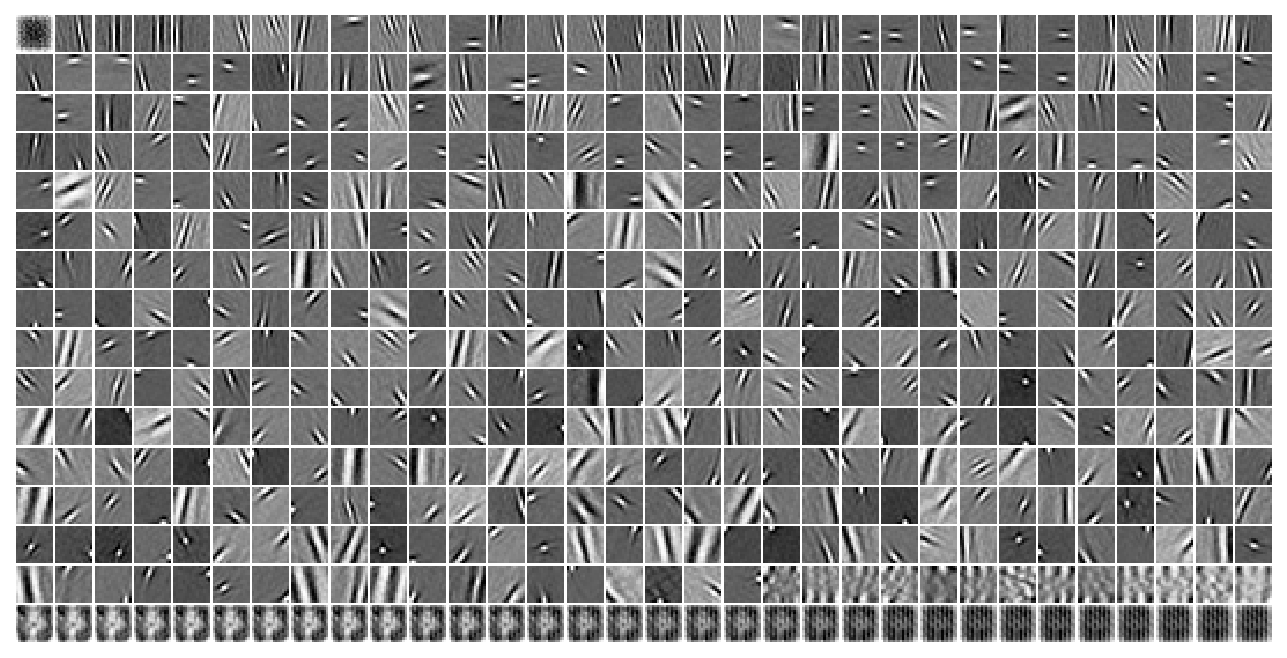

In [28]:
tr.model.show(order=np.argsort(u0));

bad ones: last 1 row(s), plus the last 14 elements from the row above

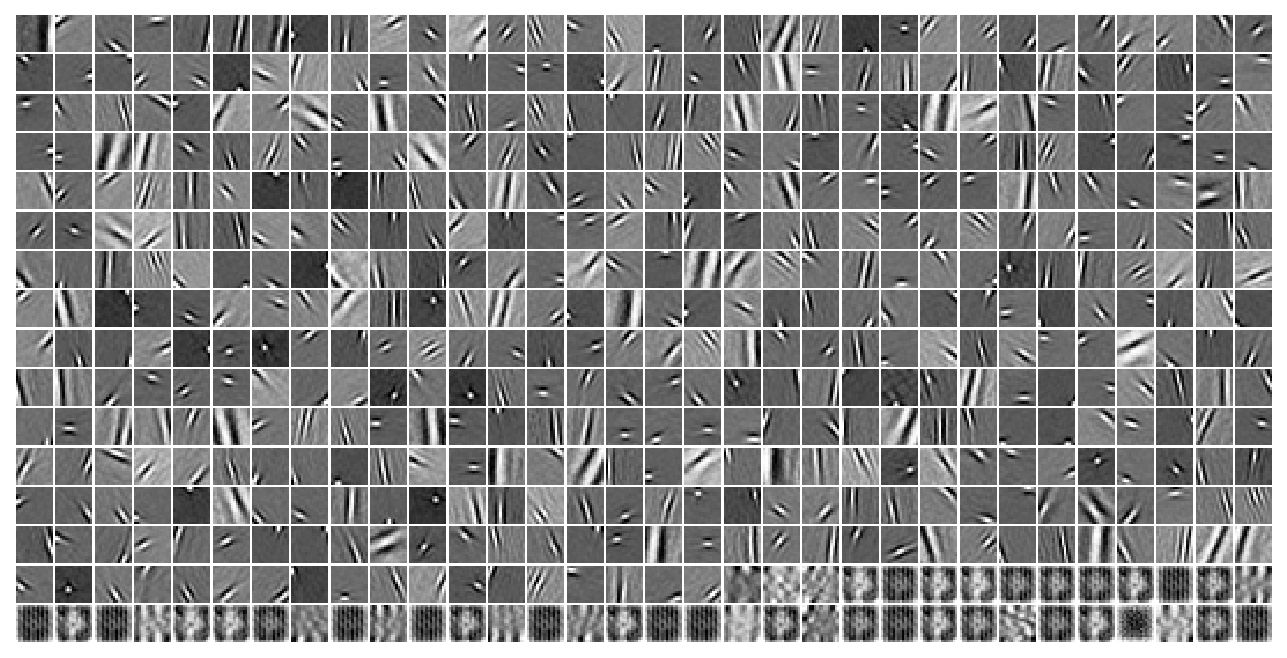

In [29]:
bad_rows = bad_indices.sum() // (512 // 16)
bad_elements = bad_indices.sum() % (512 // 16)

print(f"bad ones: last {bad_rows} row(s), plus the last {bad_elements} elements from the row above")

tr.model.show(order=np.argsort(bad_indices));

In [30]:
phi = tonp(tr.model.dec.weight.data).T
phi = phi.reshape((-1, *tr.model.cfg.input_sz))
phi_norm = np.sum(phi ** 2, axis=(1, 2, 3))

phi.shape, phi_norm.shape

((512, 1, 16, 16), (512,))

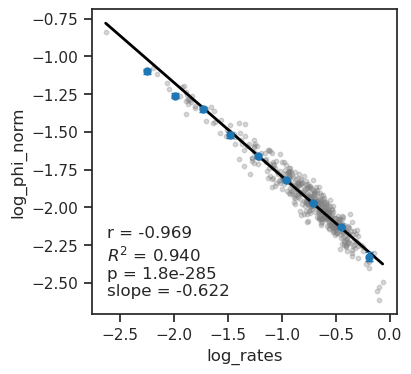

In [31]:
_ = regression_plot(
    x=u0[good_indices],
    y=np.log(phi_norm)[good_indices],
    xlabel='log_rates',
    ylabel='log_phi_norm',
)
plt.show()

In [32]:
api = wandb.Api()
run = api.run(wandb_run_id)
print(run.summary)

{'_runtime': 1552.971256798, '_step': 309000, '_timestamp': 1771989804.6174507, '_wandb': {'runtime': 1552}, 
'coeffs/beta_kl': 1, 'coeffs/lr': 1.0000002113638108e-05, 'coeffs/n_exp': 44, 'coeffs/r_max': 26.49462841926737, 
'eval/elbo': 167.4896697998047, 'eval/kl': 32.204803466796875, 'eval/kl_diag': 0.06289870291948318, 'eval/mse': 
135.2848663330078, 'eval/overall_sparse_coding': 0.5899084678627511, 'eval/r2': 0.27590182423591614, 'figs/phi': 
{'_type': 'image-file', 'format': 'png', 'height': 320, 'path': 
'media/images/figs/phi_309000_6d223f19a656529ec40c.png', 'sha256': 
'6d223f19a656529ec40c840ef4a8596f2e4c5780ae1ce8fb8c7803933c8542f3', 'size': 232239, 'width': 640}, 'sprs/lifetime':
0.666879415512085, 'sprs/population': 0.8807505369186401, 'sprs/portion_zeros': 0.585674243176359, 'train/elbo': 
166.41659545898438, 'train/loss': 166.4165802001953, 'train/loss_kl': 32.5726318359375, 'train/loss_mse': 
133.84396362304688, 'train/n_active': 478, 'train/n_active_ratio': 0.93359375, 'train/perdim_kl': 
0.06361842155456543, 'train/perdim_mse': 0.5228279829025269}

## Gamma

In [33]:
wandb_run_id = 'pal-lab/MCFE/latgt723'

tr, meta = load_model(target_path=wandb_run_id, verbose=True)

Path 'pal-lab/MCFE/latgt723' matches WandB format. Fetching config...

# params: 263.4 K

Successfully loaded model from 
/home/hadi/Projects/MCFE/checkpoints/gamma_vH16-wht_z-512/b(1000)-ep(3000)-lr(0.001)_betas(kl-1,recon-1)/2026_02_24
,19:48

Checkpoint File: GammaVAE+Trainer-3000_(2026_02_24,20:15).pt

In [34]:
print(meta)

{
    'created_timestamp': '2026_02_24,19:48',
    'checkpoint': 3000,
    'global_step': 309000,
    'root': 
'/home/hadi/Projects/MCFE/checkpoints/gamma_vH16-wht_z-512/b(1000)-ep(3000)-lr(0.001)_betas(kl-1,recon-1)/2026_02_2
4,19:48',
    'file': 'GammaVAE+Trainer-3000_(2026_02_24,20:15).pt'
}

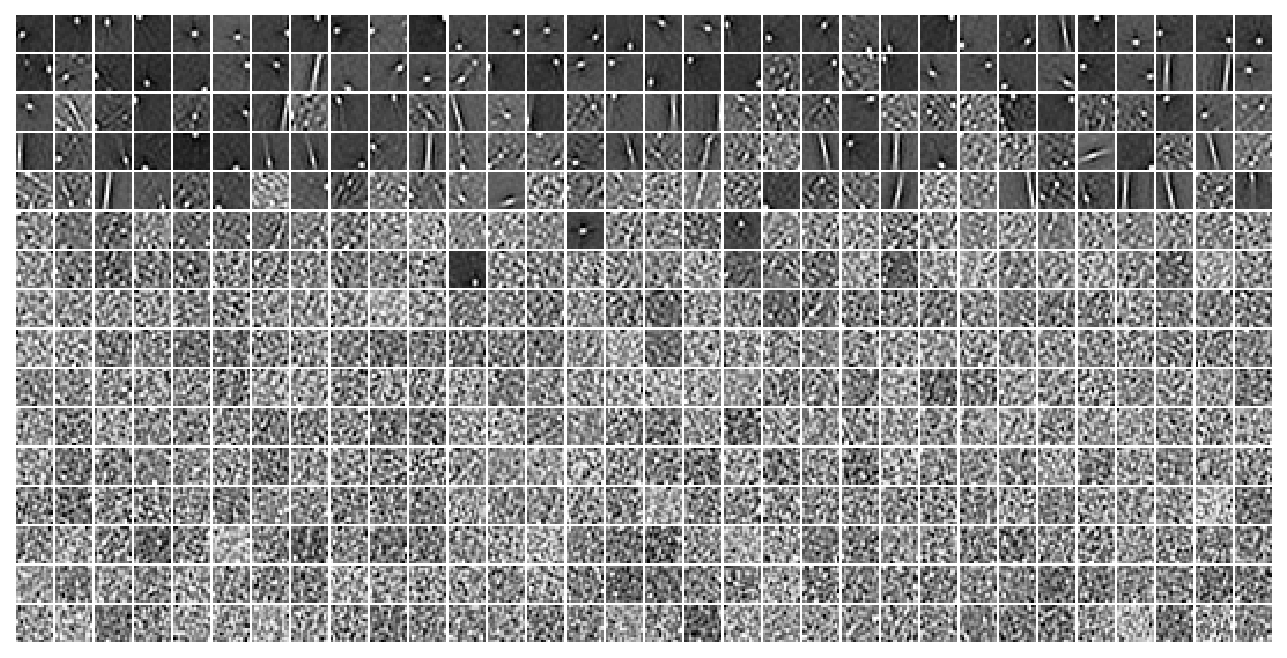

In [35]:
tr.model.show();

In [36]:
u0 = tonp(tr.model.u_init[0].squeeze())
log_alphas = tonp(tr.model.log_alpha.squeeze())

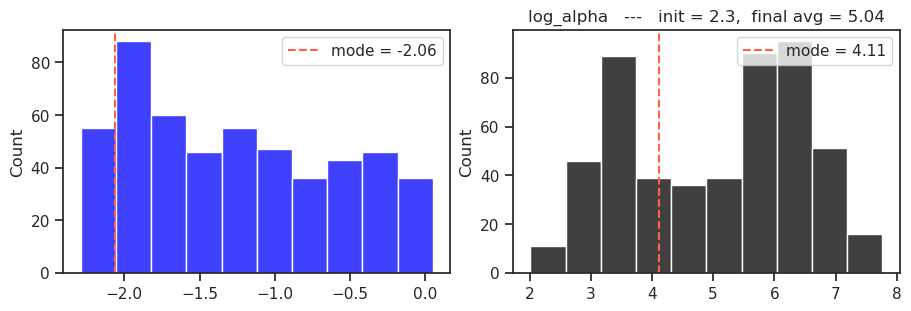

In [37]:
fig, axes = create_figure(1, 2, (9, 3))

sns.histplot(u0, color='blue', ax=axes[0])
sns.histplot(log_alphas, color='k', ax=axes[1])

u0_mode = sp_stats.mode(np.round(u0, 3)).mode
log_alphas_mode = sp_stats.mode(np.round(log_alphas, 3)).mode

axes[0].axvline(
    u0_mode,
    color='tomato',
    ls='--',
    label=f'mode = {u0_mode:0.2f}',
)
axes[1].axvline(
    log_alphas_mode,
    color='tomato',
    ls='--',
    label=f'mode = {log_alphas_mode:0.2f}',
)

axes[1].set_title(
    f"log_alpha   ---   "
    f"init = {tr.model.cfg.log_alpha_init},  "
    f"final avg = {log_alphas.mean():0.3g}"
)

add_legend(axes)

plt.show()

In [38]:
bad_indices = (u0 < -4) | (log_alphas > 20)
good_indices = np.arange(len(u0))[~bad_indices]

print(f"total num removed indices:  {bad_indices.sum()}")

total num removed indices:  0

In [39]:
u0_good = u0[good_indices]
log_alphas_good = log_alphas[good_indices]

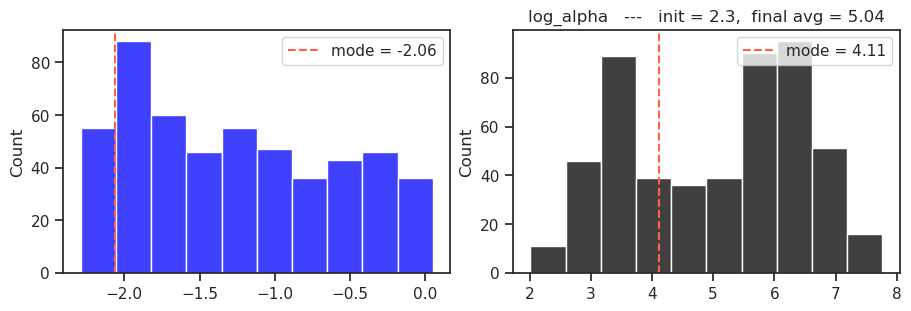

In [40]:
fig, axes = create_figure(1, 2, (9, 3))


sns.histplot(u0_good, color='blue', ax=axes[0])
sns.histplot(log_alphas_good, color='k', ax=axes[1])

u0_mode = sp_stats.mode(np.round(u0_good, 3)).mode
log_alphas_mode = sp_stats.mode(np.round(log_alphas_good, 3)).mode

axes[0].axvline(
    u0_mode,
    color='tomato',
    ls='--',
    label=f'mode = {u0_mode:0.2f}',
)
axes[1].axvline(
    log_alphas_mode,
    color='tomato',
    ls='--',
    label=f'mode = {log_alphas_mode:0.2f}',
)

axes[1].set_title(
    f"log_alpha   ---   "
    f"init = {tr.model.cfg.log_alpha_init},  "
    f"final avg = {log_alphas.mean():0.3g}"
)

add_legend(axes)

plt.show()

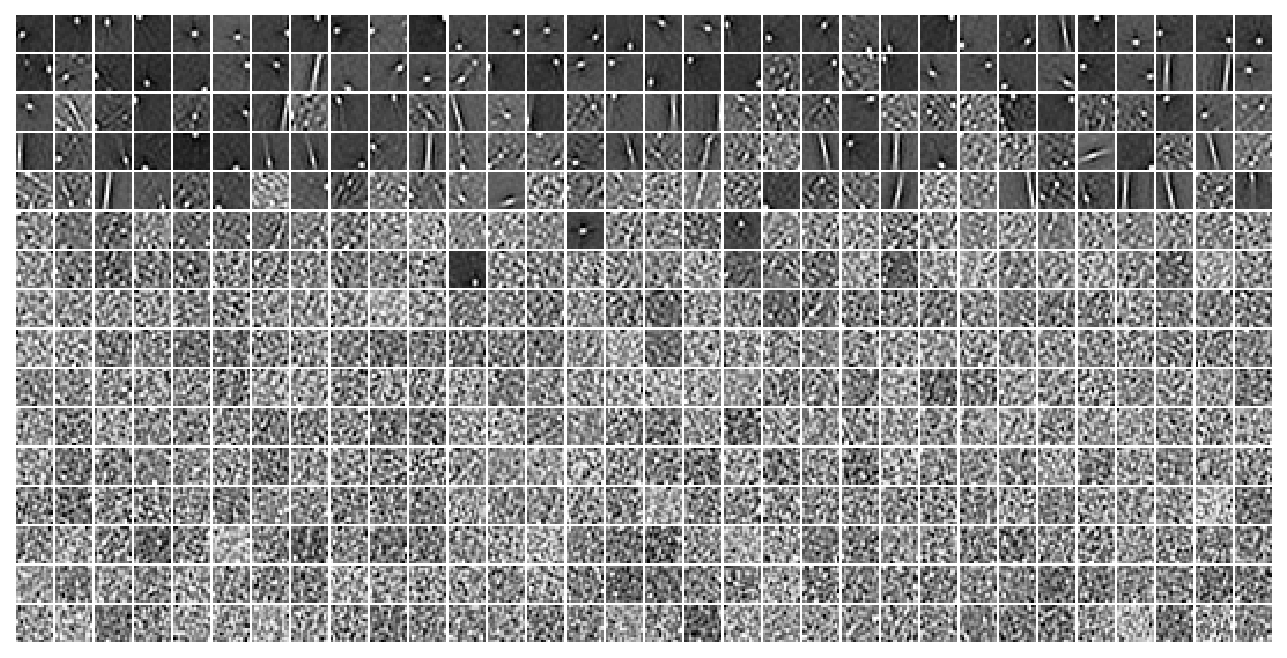

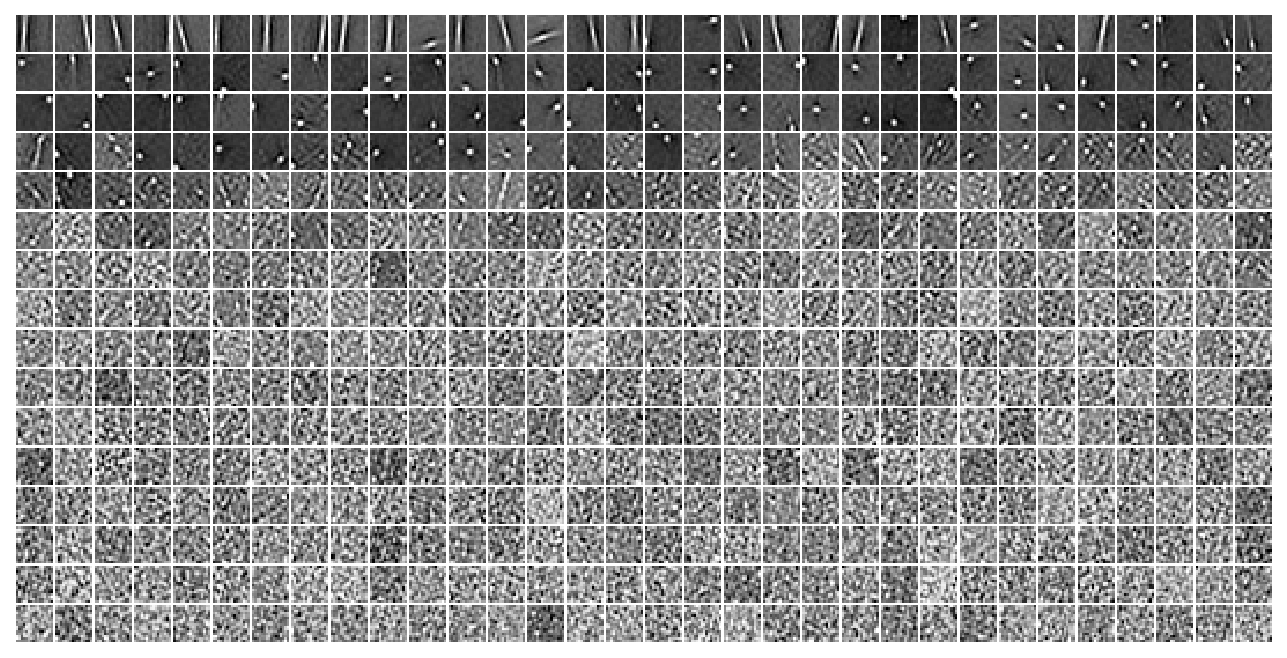

In [41]:
tr.model.show(order=np.argsort(u0));
tr.model.show(order=np.argsort(log_alphas));

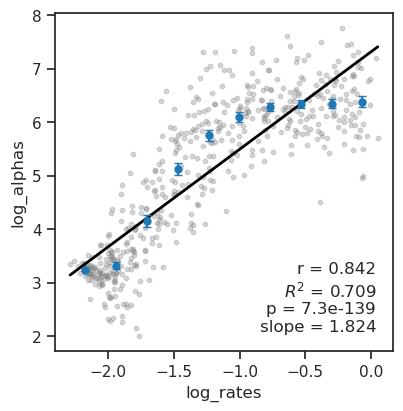

In [42]:
_ = regression_plot(
    x=u0[good_indices],
    y=log_alphas[good_indices],
    xlabel='log_rates',
    ylabel='log_alphas',
)
plt.show()

In [43]:
api = wandb.Api()
run = api.run(wandb_run_id)
print(run.summary)

{'_runtime': 1591.662408281, '_step': 309000, '_timestamp': 1771992915.7750242, '_wandb': {'runtime': 1591}, 
'coeffs/beta_kl': 1, 'coeffs/lr': 1.0000002113638108e-05, 'eval/elbo': 167.8967742919922, 'eval/kl': 
33.70502471923828, 'eval/kl_diag': 0.0658302828669548, 'eval/mse': 134.1917266845703, 'eval/overall_sparse_coding':
0.8699474884085427, 'eval/r2': 0.283329039812088, 'figs/phi': {'_type': 'image-file', 'format': 'png', 'height': 
320, 'path': 'media/images/figs/phi_309000_8abdd70b1bcf8b194a92.png', 'sha256': 
'8abdd70b1bcf8b194a92a9845ef72043ae00a500c9463db1d880b51cd46ed090', 'size': 328002, 'width': 640}, 'sprs/lifetime':
0.020382249727845192, 'sprs/population': 0.2798403203487396, 'sprs/portion_zeros': 0, 'train/elbo': 
167.0607032775879, 'train/loss': 167.06069946289062, 'train/loss_kl': 33.9512825012207, 'train/loss_mse': 
133.1094207763672, 'train/n_active': 312, 'train/n_active_ratio': 0.609375, 'train/perdim_kl': 0.06631109863519669,
'train/perdim_mse': 0.5199586749076843}

## Inverse Gaussian

In [44]:
wandb_run_id = 'pal-lab/MCFE/lxrjadab'

tr, meta = load_model(target_path=wandb_run_id, verbose=True)

Path 'pal-lab/MCFE/lxrjadab' matches WandB format. Fetching config...

# params: 263.4 K

Successfully loaded model from 
/home/hadi/Projects/MCFE/checkpoints/ig_vH16-wht_z-512/b(1000)-ep(3000)-lr(0.001)_betas(kl-1,recon-1)/2026_02_24,19
:48

Checkpoint File: InverseGaussianVAE+Trainer-3000_(2026_02_24,20:17).pt

In [45]:
print(meta)

{
    'created_timestamp': '2026_02_24,19:48',
    'checkpoint': 3000,
    'global_step': 309000,
    'root': 
'/home/hadi/Projects/MCFE/checkpoints/ig_vH16-wht_z-512/b(1000)-ep(3000)-lr(0.001)_betas(kl-1,recon-1)/2026_02_24,1
9:48',
    'file': 'InverseGaussianVAE+Trainer-3000_(2026_02_24,20:17).pt'
}

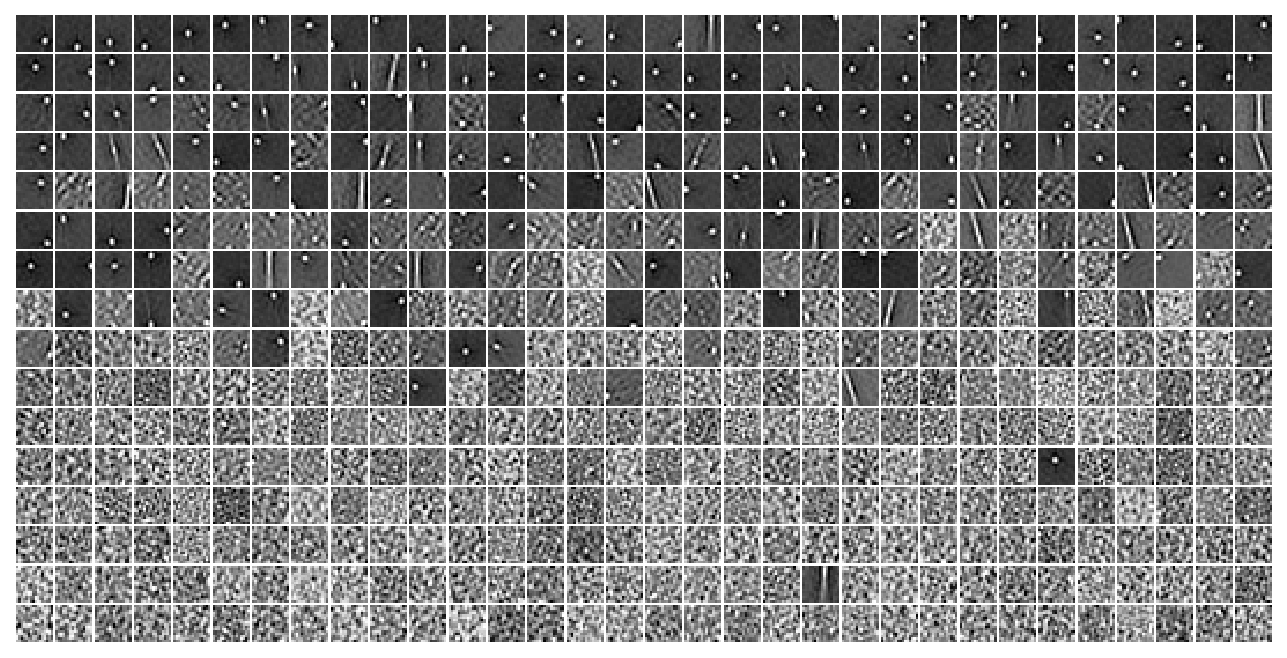

In [46]:
tr.model.show();

In [47]:
u0 = tonp(tr.model.u_init[0].squeeze())
log_alphas = tonp(tr.model.log_alpha.squeeze())

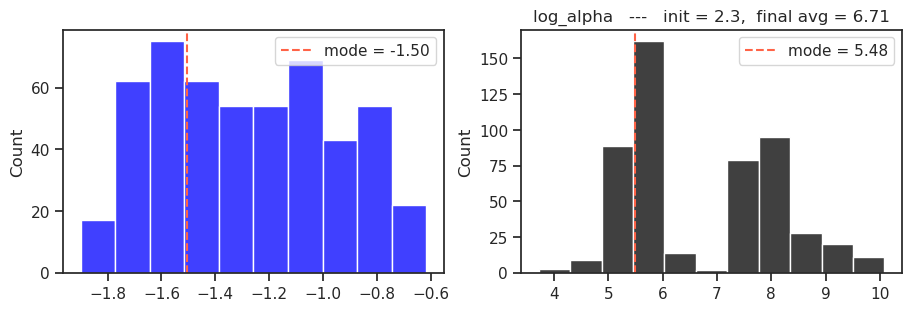

In [48]:
fig, axes = create_figure(1, 2, (9, 3))

sns.histplot(u0, color='blue', ax=axes[0])
sns.histplot(log_alphas, color='k', ax=axes[1])

u0_mode = sp_stats.mode(np.round(u0, 3)).mode
log_alphas_mode = sp_stats.mode(np.round(log_alphas, 3)).mode

axes[0].axvline(
    u0_mode,
    color='tomato',
    ls='--',
    label=f'mode = {u0_mode:0.2f}',
)
axes[1].axvline(
    log_alphas_mode,
    color='tomato',
    ls='--',
    label=f'mode = {log_alphas_mode:0.2f}',
)

axes[1].set_title(
    f"log_alpha   ---   "
    f"init = {tr.model.cfg.log_alpha_init},  "
    f"final avg = {log_alphas.mean():0.3g}"
)

add_legend(axes)

plt.show()

In [49]:
bad_indices = (u0 < -4) | (log_alphas > 20)
good_indices = np.arange(len(u0))[~bad_indices]

print(f"total num removed indices:  {bad_indices.sum()}")

total num removed indices:  0

In [50]:
u0_good = u0[good_indices]
log_alphas_good = log_alphas[good_indices]

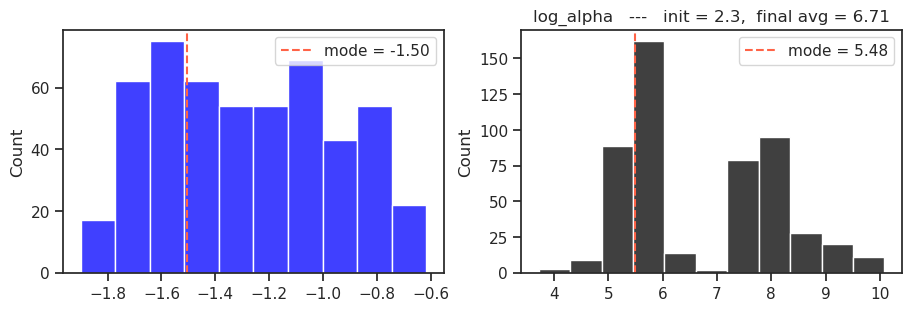

In [51]:
fig, axes = create_figure(1, 2, (9, 3))


sns.histplot(u0_good, color='blue', ax=axes[0])
sns.histplot(log_alphas_good, color='k', ax=axes[1])

u0_mode = sp_stats.mode(np.round(u0_good, 3)).mode
log_alphas_mode = sp_stats.mode(np.round(log_alphas_good, 3)).mode

axes[0].axvline(
    u0_mode,
    color='tomato',
    ls='--',
    label=f'mode = {u0_mode:0.2f}',
)
axes[1].axvline(
    log_alphas_mode,
    color='tomato',
    ls='--',
    label=f'mode = {log_alphas_mode:0.2f}',
)

axes[1].set_title(
    f"log_alpha   ---   "
    f"init = {tr.model.cfg.log_alpha_init},  "
    f"final avg = {log_alphas.mean():0.3g}"
)

add_legend(axes)

plt.show()

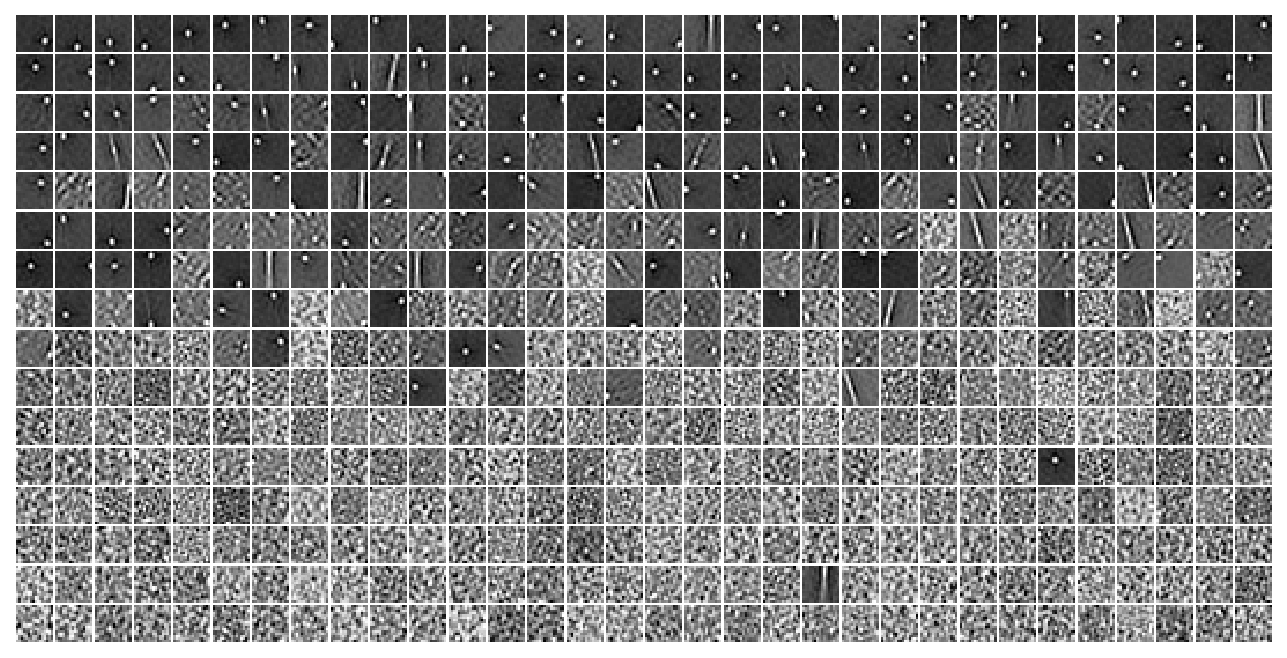

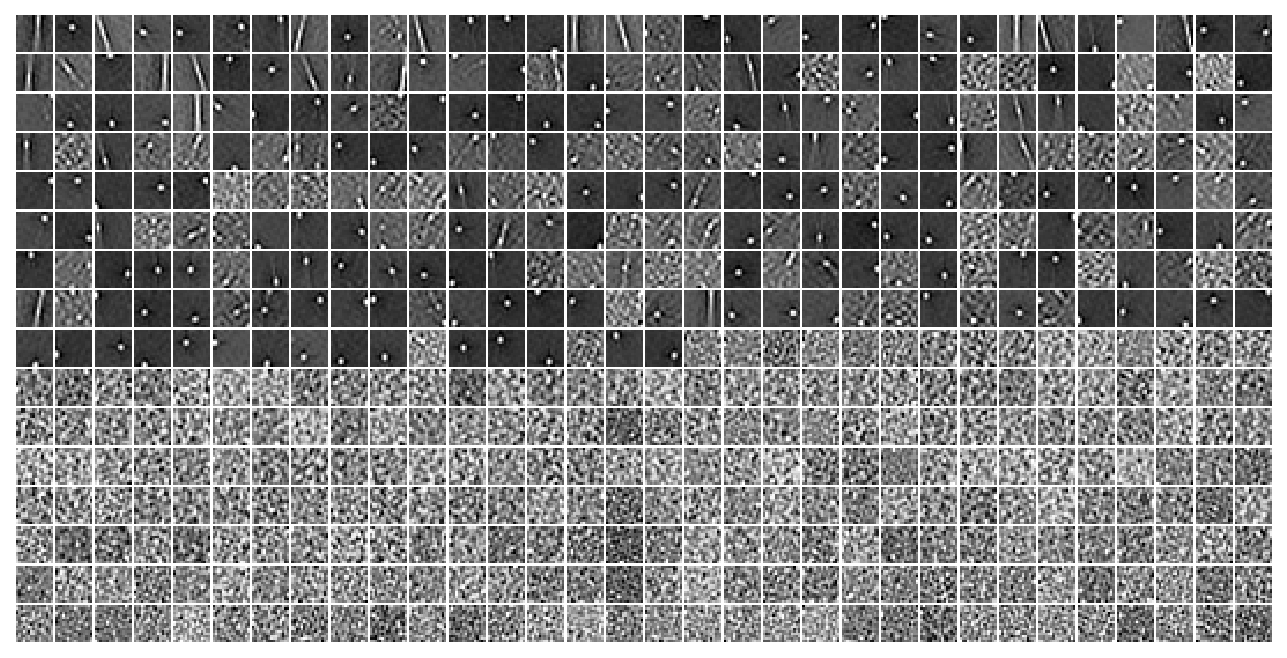

In [52]:
tr.model.show(order=np.argsort(u0));
tr.model.show(order=np.argsort(log_alphas));

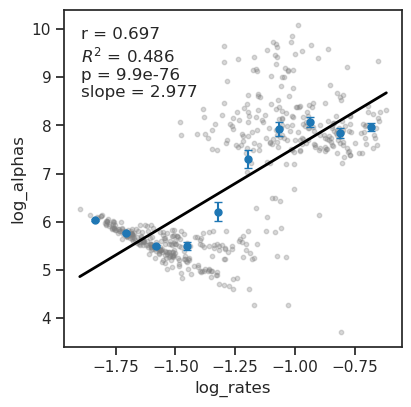

In [53]:
_ = regression_plot(
    x=u0[good_indices],
    y=log_alphas[good_indices],
    xlabel='log_rates',
    ylabel='log_alphas',
)
plt.show()

In [54]:
api = wandb.Api()
run = api.run(wandb_run_id)
print(run.summary)

{'_runtime': 1742.967993577, '_step': 309000, '_timestamp': 1771993062.5186863, '_wandb': {'runtime': 1742}, 
'coeffs/beta_kl': 1, 'coeffs/lr': 1.0000002113638108e-05, 'eval/elbo': 168.1284942626953, 'eval/kl': 
33.705867767333984, 'eval/kl_diag': 0.06583204865455627, 'eval/mse': 134.42263793945312, 
'eval/overall_sparse_coding': 0.870267704632985, 'eval/r2': 0.28255191445350647, 'figs/phi': {'_type': 
'image-file', 'format': 'png', 'height': 320, 'path': 'media/images/figs/phi_309000_2eafa99445370dcd4e51.png', 
'sha256': '2eafa99445370dcd4e51b4640f8aa0fee7a244c6b1035c571d779d50e7a464b5', 'size': 300190, 'width': 640}, 
'sprs/lifetime': 0.012826567515730858, 'sprs/population': 0.10457205772399902, 'sprs/portion_zeros': 0, 
'train/elbo': 167.30533981323242, 'train/loss': 167.3053436279297, 'train/loss_kl': 33.90607833862305, 
'train/loss_mse': 133.39926147460938, 'train/n_active': 422, 'train/n_active_ratio': 0.82421875, 'train/perdim_kl':
0.06622280925512314, 'train/perdim_mse': 0.5210908651351929}